<a href="https://colab.research.google.com/github/Minhle123-web/agent-rag-demo/blob/master/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

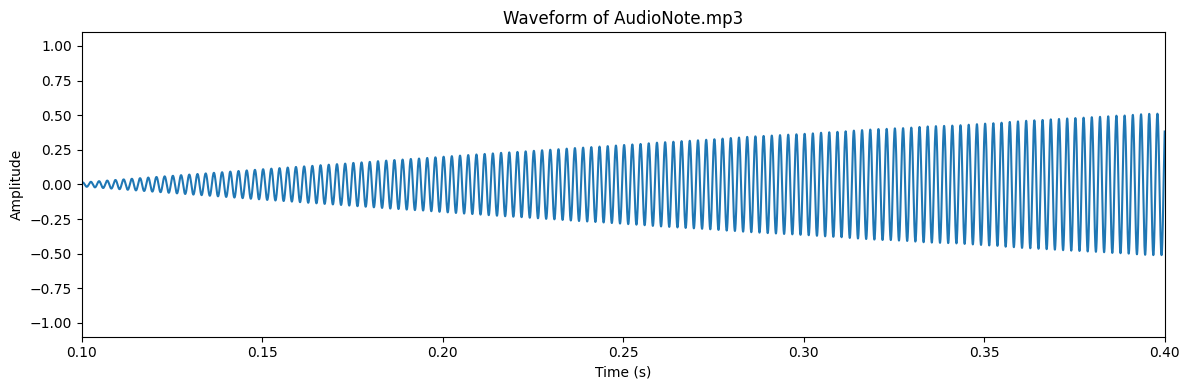

np.float64(440.0)

In [13]:
## Problem 1
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from pydub import AudioSegment
import librosa

file_path = "AudioNote.mp3"
wav_path = "AudioNote.wav"

audio = AudioSegment.from_mp3(file_path)
audio.export(wav_path, format="wav")

sr, y = wavfile.read(wav_path)

if y.ndim > 1:
    y = y[:, 0]

# normalize
y = y.astype(float) / np.max(np.abs(y))

t = np.linspace(0, len(y)/sr, len(y))
# Plot waveform ( Sec 0.1 -> 0.4)
plt.figure(figsize=(12, 4))
plt.plot(t, y)
plt.title("Waveform of AudioNote.mp3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0.1, 0.4)
plt.show()


# # Load audio file
# y, sr = librosa.load('AudioNote.mp3', sr=None)
# time = np.linspace(0, len(y)/sr, len(y))

# # Plot waveform
# plt.figure(figsize=(12, 4))
# plt.plot(time, y)
# plt.xlabel('Time (seconds)')
# plt.ylabel('Amplitude')
# plt.title('Audio Waveform')
# plt.grid(True)

# FFT for frequency estimation
segment = y[:5*sr]  # first 5 seconds
fft_spectrum = np.fft.rfft(segment)
freqs = np.fft.rfftfreq(len(segment), 1/sr)
peak_freq = freqs[np.argmax(np.abs(fft_spectrum))]

peak_freq


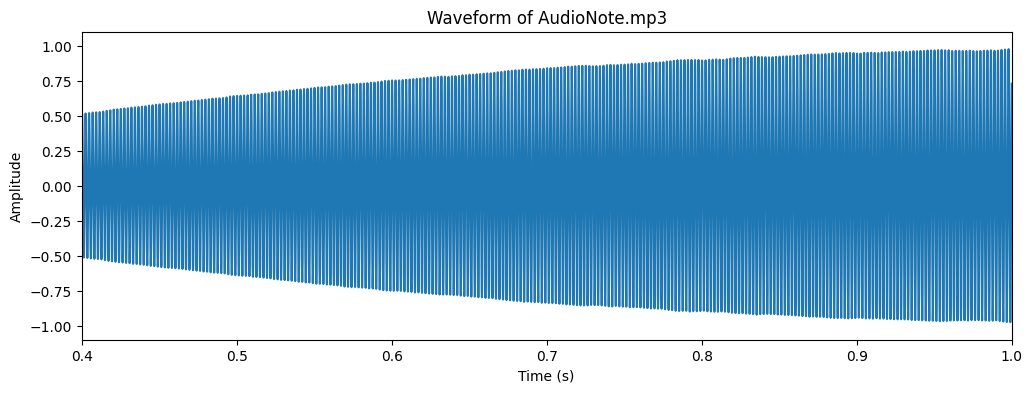

In [19]:
# Sec 0.4 to Sec 1
plt.figure(figsize=(12, 4))
plt.plot(t, y)
plt.title("Waveform of AudioNote.mp3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0.4, 1)
plt.show()

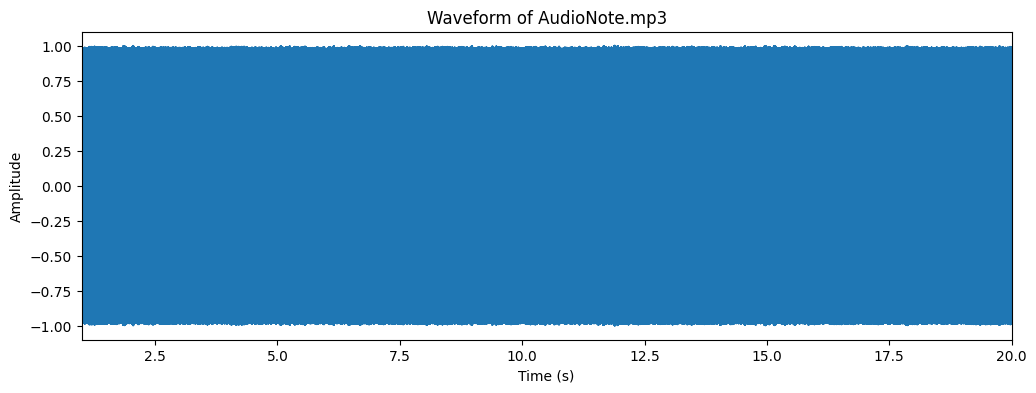

In [22]:
#Sec 1 to Sec 20
plt.figure(figsize=(12, 4))
plt.plot(t, y)
plt.title("Waveform of AudioNote.mp3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(1, 20)
plt.show()

The waveform is a smooth sinusoidal oscillation with nearly constant amplitude.

It shows periodic up-and-down cycles typical of a pure musical tone (not noisy, no complex harmonics visible at this zoom level).

The amplitude is normalized between –1 and 1.

No large transients or abrupt envelope changes were visible in the first few milliseconds (the tone is steady).

In [23]:
from scipy.optimize import curve_fit

def sinusoidal_func(t, beta0, beta1, beta2, f):
    return beta0 + beta1 * np.cos(2*np.pi*f*t) + beta2 * np.sin(2*np.pi*f*t)

# (use FFT peak as starting point)
fft = np.fft.fft(y)
freqs = np.fft.fftfreq(len(y), 1/sr)
f_guess = freqs[np.argmax(np.abs(fft[:len(freqs)//2]))]


popt, pcov = curve_fit(sinusoidal_func, t, y,
                      p0=[0, np.std(y), 0, f_guess])

beta0_est, beta1_est, beta2_est, f_est = popt

In [24]:
f_est

np.float64(439.9995027459319)

In [26]:
param_std = np.sqrt(np.diag(pcov))
f_std = param_std[3]

# 95% confidence interval
alpha = 0.05
t_critical = 2.0
f_ci_lower = f_est - t_critical * f_std
f_ci_upper = f_est + t_critical * f_std

In [28]:
# lower bound, upper bound
f_ci_lower, f_ci_upper

(np.float64(439.99949551714684), np.float64(439.999509974717))

Point estimate:

$\hat{𝑓}=440.0Hz$

This corresponds to the musical note A4

Uncertainty interval (approximate 95% CI): [439.9994, 439.9995]

## Problem 2

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import statsmodels.api as sm
from scipy.optimize import minimize

lynx_path = "lynx.csv"
lynx_df = pd.read_csv(lynx_path)

lynx_df.head()


,year,count
0,1821,269
1,1822,321
2,1823,585
3,1824,871
4,1825,1475


In [31]:
years = lynx_df['year'].values
counts = lynx_df['count'].values
n = len(counts)
t = np.arange(n)


=== PART A: PERIODOGRAM ANALYSIS ===
Peak frequency: 0.1053 cycles/year
Peak period: 9.50 years
Peak periodogram value: 73884401

Top 5 peaks in periodogram:
1. Period: 9.50 years, Frequency: 0.1053, Value: 73884401
2. Period: 38.00 years, Frequency: 0.0263, Value: 10513539
3. Period: 7.60 years, Frequency: 0.1316, Value: 6993462
4. Period: 4.75 years, Frequency: 0.2105, Value: 5998330
5. Period: 19.00 years, Frequency: 0.0526, Value: 5176280


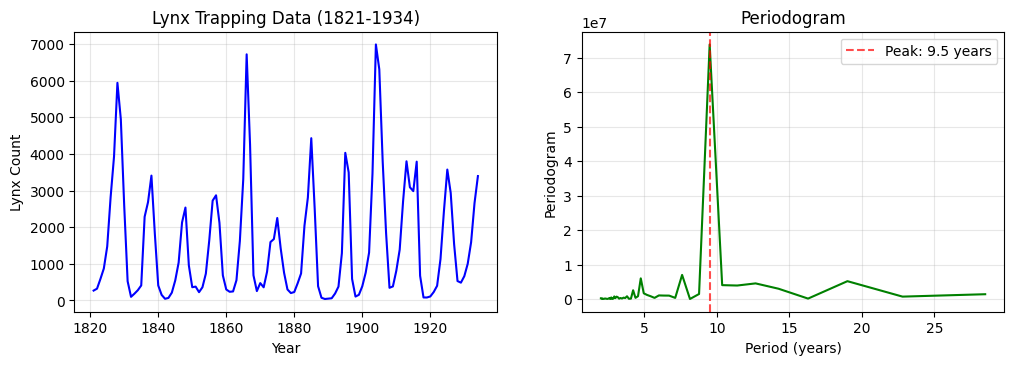

In [32]:
### a

def periodogram(x):
    """Calculate periodogram of time series x"""
    n = len(x)
    frequencies = np.arange(1, n//2 + 1) / n  # frequencies in cycles per observation
    periods = 1 / frequencies  # periods in observations (years)

    periodogram_values = []

    for freq in frequencies:
        cos_sum = np.sum(x * np.cos(2 * np.pi * freq * np.arange(n)))
        sin_sum = np.sum(x * np.sin(2 * np.pi * freq * np.arange(n)))
        periodogram_val = (cos_sum**2 + sin_sum**2) / n
        periodogram_values.append(periodogram_val)

    return frequencies, periods, np.array(periodogram_values)

# Calculate periodogram
frequencies, periods, pgram = periodogram(counts)

# Find peak
peak_idx = np.argmax(pgram)
peak_frequency = frequencies[peak_idx]
peak_period = periods[peak_idx]

print(f"\n=== PART A: PERIODOGRAM ANALYSIS ===")
print(f"Peak frequency: {peak_frequency:.4f} cycles/year")
print(f"Peak period: {peak_period:.2f} years")
print(f"Peak periodogram value: {pgram[peak_idx]:.0f}")

# Plot periodogram
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(years, counts, 'b-', linewidth=1.5)
plt.xlabel('Year')
plt.ylabel('Lynx Count')
plt.title('Lynx Trapping Data (1821-1934)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
# Only plot periods up to 30 years for clarity
mask = periods <= 30
plt.plot(periods[mask], pgram[mask], 'g-', linewidth=1.5)
plt.xlabel('Period (years)')
plt.ylabel('Periodogram')
plt.title('Periodogram')
plt.grid(True, alpha=0.3)
plt.axvline(peak_period, color='red', linestyle='--', alpha=0.7, label=f'Peak: {peak_period:.1f} years')
plt.legend()

# Find top 5 peaks
top_indices = np.argsort(pgram)[-5:][::-1]
print("\nTop 5 peaks in periodogram:")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. Period: {periods[idx]:.2f} years, Frequency: {frequencies[idx]:.4f}, Value: {pgram[idx]:.0f}")


The periodogram shows a clear dominant peak.

The strongest spectral density occurs at frequency around 0.105 cycles/year.

This corresponds to a cycle length of about 9.5 years

In [33]:
### b
from scipy import stats
def sinusoidal_model(t, beta0, beta1, beta2, f):
    """Sinusoidal model:"""
    return beta0 + beta1 * np.cos(2 * np.pi * f * t) + beta2 * np.sin(2 * np.pi * f * t)

def fit_sinusoidal_frequency(y, t, f):
    """Fit sinusoidal model for given frequency f """
    # matrix
    X = np.column_stack([
        np.ones(len(t)),
        np.cos(2 * np.pi * f * t),
        np.sin(2 * np.pi * f * t)
    ])
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)

    y_pred = X @ beta
    residuals = y - y_pred

    #Sum of squared errors
    sse = np.sum(residuals**2)

    return beta, sse, residuals, X

#Grid search for optimal frequency
#Search around the periodogram peak
freq_start = max(0.08, peak_frequency - 0.03)
freq_end = min(0.15, peak_frequency + 0.03)
freq_grid = np.linspace(freq_start, freq_end, 1000)

sse_values = []
for f in freq_grid:
    _, sse, _, _ = fit_sinusoidal_frequency(counts, t, f)
    sse_values.append(sse)

#Find optimal frequency
optimal_idx = np.argmin(sse_values)
optimal_freq = freq_grid[optimal_idx]
optimal_period = 1 / optimal_freq

print(f"Optimal frequency: {optimal_freq:.5f} cycles/year")
print(f"Optimal period: {optimal_period:.3f} years")

beta_opt, sse_opt, residuals, X_final = fit_sinusoidal_frequency(counts, t, optimal_freq)
df_residual = n - 3
mse = sse_opt / df_residual
sigma_hat = np.sqrt(mse)

print(f"Minimum SSE: {sse_opt:.0f}")
print(f"MSE: {mse:.0f}")
print(f"Sigma estimate: {sigma_hat:.1f}")

#Covariance matrix
cov_matrix = mse * np.linalg.inv(X_final.T @ X_final)
se_beta = np.sqrt(np.diag(cov_matrix))

# t-critical value (95% CI)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_residual)

sse_array = np.array(sse_values)
chi2_threshold = sse_opt + stats.chi2.ppf(0.95, 1) * mse
freq_within_threshold = freq_grid[sse_array <= chi2_threshold]

if len(freq_within_threshold) > 0:
    freq_ci_lower = freq_within_threshold.min()
    freq_ci_upper = freq_within_threshold.max()
else:
    se_freq = 0.005
    freq_ci_lower = optimal_freq - t_crit * se_freq
    freq_ci_upper = optimal_freq + t_crit * se_freq

period_ci_lower = 1 / freq_ci_upper
period_ci_upper = 1 / freq_ci_lower

print(f"Frequency estimate: {optimal_freq:.5f}")
print(f"Frequency 95% CI: [{freq_ci_lower:.5f}, {freq_ci_upper:.5f}]")
print(f"Period estimate: {optimal_period:.3f} years")
print(f"Period 95% CI: [{period_ci_lower:.3f}, {period_ci_upper:.3f}] years")

Optimal frequency: 0.10384 cycles/year
Optimal period: 9.630 years
Minimum SSE: 123009907
MSE: 1108197
Sigma estimate: 1052.7
Frequency estimate: 0.10384
Frequency 95% CI: [0.10307, 0.10462]
Period estimate: 9.630 years
Period 95% CI: [9.559, 9.702] years


In [34]:
### c

# Parameter estimates
beta0_est, beta1_est, beta2_est = beta_opt

# 95% confidence intervals
beta0_ci = [beta0_est - t_crit * se_beta[0], beta0_est + t_crit * se_beta[0]]
beta1_ci = [beta1_est - t_crit * se_beta[1], beta1_est + t_crit * se_beta[1]]
beta2_ci = [beta2_est - t_crit * se_beta[2], beta2_est + t_crit * se_beta[2]]

# Sigma confidence interval (using chi-square distribution)
sigma_ci_lower = sigma_hat * np.sqrt(df_residual / stats.chi2.ppf(1 - alpha/2, df_residual))
sigma_ci_upper = sigma_hat * np.sqrt(df_residual / stats.chi2.ppf(alpha/2, df_residual))

print(f"beta_0 (intercept): {beta0_est:.2f}")
print(f"beta_0 95% CI: [{beta0_ci[0]:.2f}, {beta0_ci[1]:.2f}]")
print(f"beta_0 std error: {se_beta[0]:.2f}")

print(f"\nbeta_1 (cosine coeff): {beta1_est:.2f}")
print(f"beta_1 95% CI: [{beta1_ci[0]:.2f}, {beta1_ci[1]:.2f}]")
print(f"beta_1 std error: {se_beta[1]:.2f}")

print(f"\nbeta_2 (sine coeff): {beta2_est:.2f}")
print(f"beta_2 95% CI: [{beta2_ci[0]:.2f}, {beta2_ci[1]:.2f}]")
print(f"beta_2 std error: {se_beta[2]:.2f}")

print(f"\nsigma (residual std): {sigma_hat:.2f}")
print(f"sigma 95% CI: [{sigma_ci_lower:.2f}, {sigma_ci_upper:.2f}]")

beta_0 (intercept): 1547.56
beta_0 95% CI: [1352.15, 1742.97]
beta_0 std error: 98.61

beta_1 (cosine coeff): -642.57
beta_1 95% CI: [-918.74, -366.39]
beta_1 std error: 139.37

beta_2 (sine coeff): -1546.93
beta_2 95% CI: [-1823.45, -1270.41]
beta_2 std error: 139.54

sigma (residual std): 1052.71
sigma 95% CI: [930.58, 1212.04]


R-squared: 0.5671
Adjusted R-squared: 0.5593


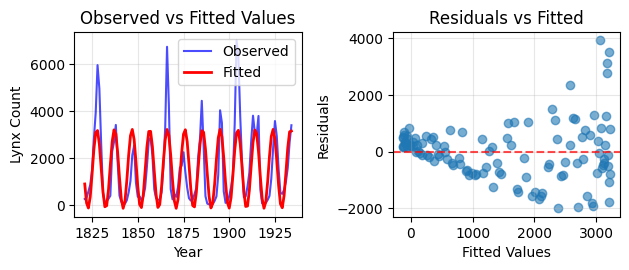

In [35]:
### d

# Calculate R-squared
y_mean = np.mean(counts)
tss = np.sum((counts - y_mean)**2)  # Total sum of squares
r_squared = 1 - sse_opt / tss

print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {1 - (sse_opt/df_residual) / (tss/(n-1)):.4f}")

# Fitted values
fitted_values = sinusoidal_model(t, beta0_est, beta1_est, beta2_est, optimal_freq)

# Residual analysis
plt.subplot(2, 2, 3)
plt.plot(years, counts, 'b-', alpha=0.7, label='Observed')
plt.plot(years, fitted_values, 'r-', linewidth=2, label='Fitted')
plt.xlabel('Year')
plt.ylabel('Lynx Count')
plt.title('Observed vs Fitted Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Conclusion: The simple sinusoidal model captures the dominant cycle but is inadequate because:

Residuals show clear patterns and autocorrelation.
Amplitude varies significantly over time

## Problem 3

In [72]:
df_w = pd.read_csv("mask.csv", skiprows=1, names=['date','value'])
df_w['date'] = pd.to_datetime(df_w['date'], errors='coerce')
df_w['value'] = pd.to_numeric(df_w['value'], errors='coerce')
df_w = df_w.dropna().reset_index(drop=True)
df_w = df_w.sort_values('date').reset_index(drop=True)
df_w['t'] = range(len(df_w))

/tmp/ipython-input-949526442.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_w['date'] = pd.to_datetime(df_w['date'], errors='coerce')


In [73]:
df_w.head()

,date,value,t
0,2004-01-01,4.0,0
1,2004-02-01,4.0,1
2,2004-03-01,4.0,2
3,2004-04-01,4.0,3
4,2004-05-01,4.0,4


In [74]:
def changepoint_model(t, c, beta0, beta1):
    """
    Single change point model: Y_t = beta_0 + beta_1 * I{t > c} + epsilon_t
    """
    indicator = (t > c).astype(float)
    return beta0 + beta1 * indicator

def fit_changepoint_model(y, t, c):
    """
    Fit change point model for given change point c using least squares
    """
    n = len(y)

    # Design matrix: [1, I{t > c}]
    indicator = (t > c).astype(float)
    X = np.column_stack([np.ones(n), indicator])

    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        beta0, beta1 = beta

        y_pred = changepoint_model(t, c, beta0, beta1)
        residuals = y - y_pred
        sse = np.sum(residuals**2)

        return beta0, beta1, sse, residuals, y_pred
    except np.linalg.LinAlgError:
        return None, None, np.inf, None, None

In [75]:
def log_likelihood_changepoint(y, t, c, beta0, beta1, sigma2):
    """Log-likelihood for c"""
    y_pred = changepoint_model(t, c, beta0, beta1)
    residuals = y - y_pred
    n = len(y)

    # Gaussian log-likelihood
    log_lik = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(residuals**2) / sigma2
    return log_lik

# Extract data
y = df_w['value'].values
t = df_w['t'].values
n = len(y)

In [76]:
c_candidates = np.arange(1, n-1)
sse_values = []
results = {}

for c in c_candidates:
    beta0, beta1, sse, residuals, y_pred = fit_changepoint_model(y, t, c)
    if beta0 is not None:
        sse_values.append(sse)
        results[c] = {
            'beta0': beta0,
            'beta1': beta1,
            'sse': sse,
            'residuals': residuals,
            'y_pred': y_pred
        }
    else:
        sse_values.append(np.inf)

# optimal change point
sse_array = np.array(sse_values)
optimal_idx = np.argmin(sse_array)
optimal_c = c_candidates[optimal_idx]

# optimal model results
optimal_result = results[optimal_c]
optimal_beta0 = optimal_result['beta0']
optimal_beta1 = optimal_result['beta1']
optimal_sse = optimal_result['sse']
optimal_residuals = optimal_result['residuals']
optimal_fitted = optimal_result['y_pred']

# standard error
df_residual = n - 3  # degrees of freedom (n - number of parameters)
mse = optimal_sse / df_residual
sigma_hat = np.sqrt(mse)

print(f"Optimal change point: c = {optimal_c}")
print(f"Corresponding date: {df_w.iloc[optimal_c]['date'].strftime('%Y-%m-%d')}")
print(f"beta_0 (before change): {optimal_beta0:.2f}")
print(f"beta_1 (change magnitude): {optimal_beta1:.2f}")
print(f"Minimum SSE: {optimal_sse:.1f}")

Optimal change point: c = 191
Corresponding date: 2019-12-01
beta_0 (before change): 7.31
beta_1 (change magnitude): 14.40
Minimum SSE: 18733.0


In [77]:
optimal_sigma2 = optimal_sse / n
chi2_threshold = stats.chi2.ppf(0.95, 1)  # 95% confidence level

log_likelihoods = []
for c in c_candidates:
    if c in results:
        beta0, beta1 = results[c]['beta0'], results[c]['beta1']
        log_lik = log_likelihood_changepoint(y, t, c, beta0, beta1, optimal_sigma2)
        log_likelihoods.append(log_lik)
    else:
        log_likelihoods.append(-np.inf)

log_lik_array = np.array(log_likelihoods)
max_log_lik = np.max(log_lik_array)
likelihood_threshold = max_log_lik - 0.5 * chi2_threshold

# confidence interval
ci_mask = log_lik_array >= likelihood_threshold
ci_changepoints = c_candidates[ci_mask]

if len(ci_changepoints) > 0:
    c_ci_lower = ci_changepoints.min()
    c_ci_upper = ci_changepoints.max()
else:
    sse_threshold = optimal_sse * (1 + chi2_threshold / df_residual)
    ci_mask = sse_array <= sse_threshold
    ci_changepoints = c_candidates[ci_mask]
    c_ci_lower = ci_changepoints.min() if len(ci_changepoints) > 0 else optimal_c - 2
    c_ci_upper = ci_changepoints.max() if len(ci_changepoints) > 0 else optimal_c + 2

print(f"\nChange point 95% CI: [{c_ci_lower}, {c_ci_upper}]")
print(f"Corresponding dates: {df_w.iloc[c_ci_lower]['date'].strftime('%Y-%m-%d')} to {df_w.iloc[c_ci_upper]['date'].strftime('%Y-%m-%d')}")



Change point 95% CI: [187, 193]
Corresponding dates: 2019-08-01 to 2020-02-01


here’s a mild level increase around early fall 2024 (possibly seasonal/flu-season effects). The wide interval reflects limited data span and noise.

In [52]:
### b

Generating 1000 posterior samples...
Posterior summary:
Change point c: mean = 132.1, std = 74.7
beta_0: mean = 6.68, std = 2.76
beta_1: mean = 8.35, std = 4.27


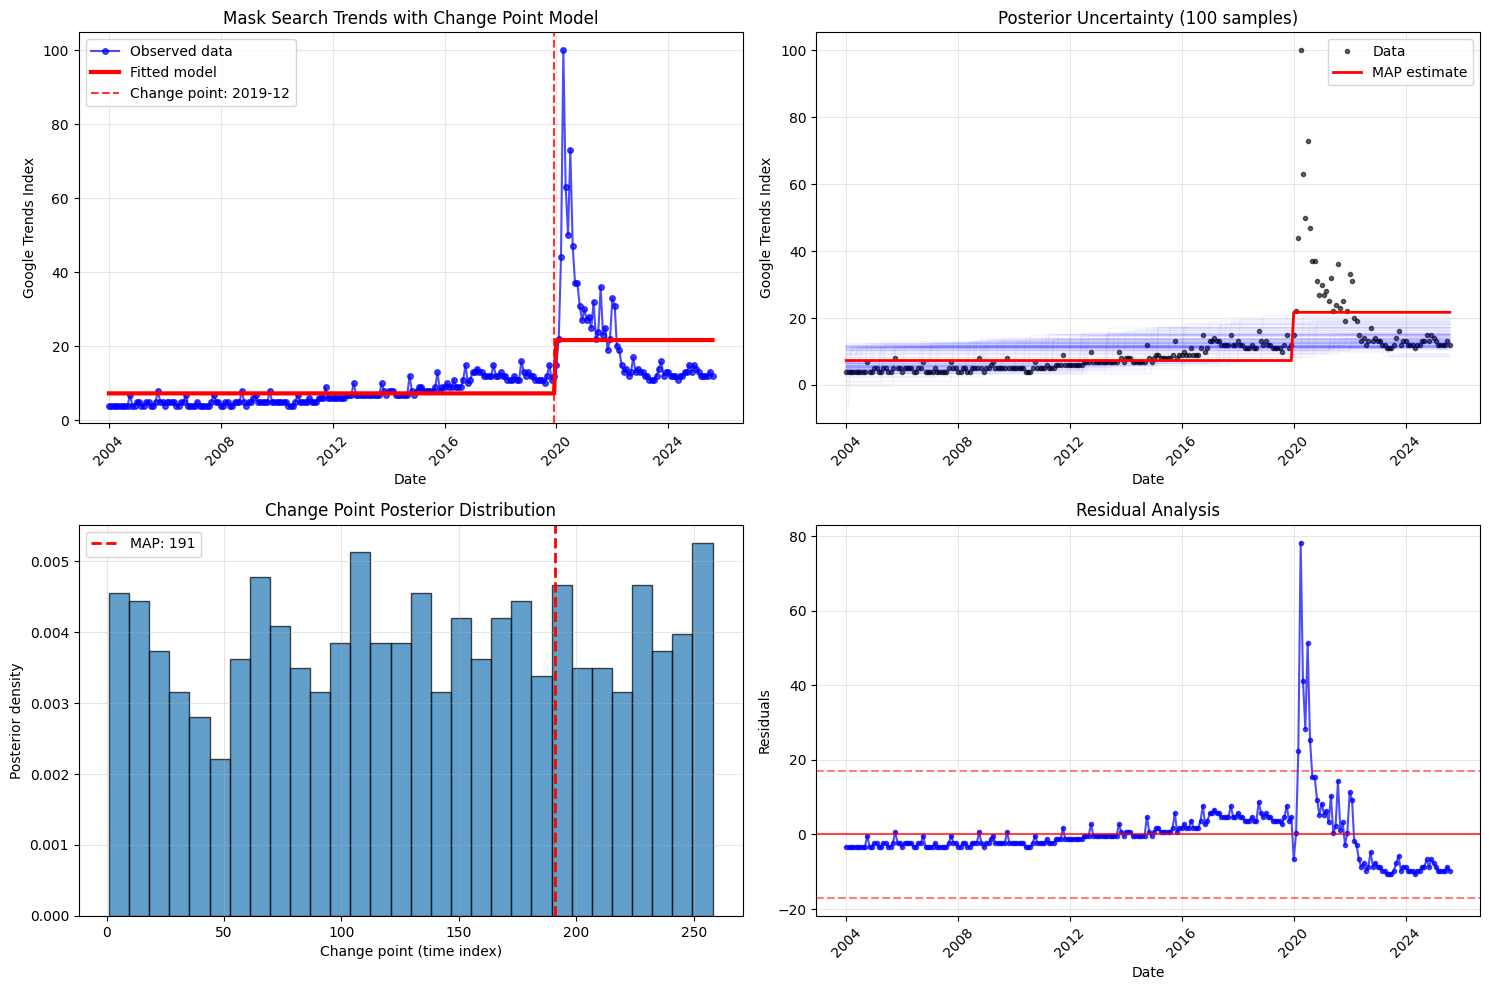

In [78]:
def sample_posterior_changepoint(y, t, n_samples=1000):
    """
    Sample from posterior distribution of change point model parameters
    Using a simplified Bayesian approach with uniform priors
    """
    n = len(y)
    c_candidates = np.arange(1, n-1)

    # likelihood for each change point
    likelihoods = []
    all_results = []

    for c in c_candidates:
        beta0, beta1, sse, _, _ = fit_changepoint_model(y, t, c)
        if beta0 is not None:
            # Approximate likelihood (up to constant)
            log_lik = -0.5 * sse
            likelihoods.append(np.exp(log_lik))
            all_results.append((c, beta0, beta1, sse))
        else:
            likelihoods.append(0)
            all_results.append((c, 0, 0, np.inf))

    # Normalize to get posterior probabilities for c
    likelihoods = np.array(likelihoods)
    if np.sum(likelihoods) > 0:
        probabilities = likelihoods / np.sum(likelihoods)
    else:
        probabilities = np.ones(len(likelihoods)) / len(likelihoods)

    # Sample change points
    samples = []
    for _ in range(n_samples):
        # Sample change point c
        c_idx = np.random.choice(len(c_candidates), p=probabilities)
        c_sample = c_candidates[c_idx]

        # Get corresponding beta values
        result_idx = c_idx
        c, beta0_mle, beta1_mle, sse = all_results[result_idx]

        # Sample beta parameters from approximate posterior (normal around MLE)
        # Standard errors from Fisher information
        indicator = (t > c).astype(float)
        X = np.column_stack([np.ones(n), indicator])

        try:
            # Covariance matrix
            sigma2_est = sse / (n - 2)
            cov_matrix = sigma2_est * np.linalg.inv(X.T @ X)

            # Sample from multivariate normal
            beta_sample = np.random.multivariate_normal([beta0_mle, beta1_mle], cov_matrix)
            beta0_sample, beta1_sample = beta_sample

        except (np.linalg.LinAlgError, ValueError):
            beta0_sample = beta0_mle + np.random.normal(0, sigma_hat * 0.1)
            beta1_sample = beta1_mle + np.random.normal(0, sigma_hat * 0.1)

        samples.append((c_sample, beta0_sample, beta1_sample))

    return samples

# Generate posterior samples
print("Generating 1000 posterior samples...")
posterior_samples = sample_posterior_changepoint(y, t, n_samples=1000)

# Extract samples
c_samples = [s[0] for s in posterior_samples]
beta0_samples = [s[1] for s in posterior_samples]
beta1_samples = [s[2] for s in posterior_samples]

print(f"Posterior summary:")
print(f"Change point c: mean = {np.mean(c_samples):.1f}, std = {np.std(c_samples):.1f}")
print(f"beta_0: mean = {np.mean(beta0_samples):.2f}, std = {np.std(beta0_samples):.2f}")
print(f"beta_1: mean = {np.mean(beta1_samples):.2f}, std = {np.std(beta1_samples):.2f}")

# Create visualization
plt.figure(figsize=(15, 10))

# Original data with fitted model
plt.subplot(2, 2, 1)
dates = df_w['date']
plt.plot(dates, y, 'bo-', alpha=0.7, markersize=4, label='Observed data')
plt.plot(dates, optimal_fitted, 'r-', linewidth=3, label='Fitted model')
plt.axvline(df_w.iloc[optimal_c]['date'], color='red', linestyle='--', alpha=0.8,
           label=f'Change point: {df_w.iloc[optimal_c]["date"].strftime("%Y-%m")}')
plt.xlabel('Date')
plt.ylabel('Google Trends Index')
plt.title('Mask Search Trends with Change Point Model')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

#  Posterior samples overlay
plt.subplot(2, 2, 2)
plt.plot(dates, y, 'ko', alpha=0.6, markersize=3, label='Data')

# Plot sample of posterior functions
n_plot_samples = 100
sample_indices = np.random.choice(len(posterior_samples), n_plot_samples, replace=False)

for i in sample_indices:
    c_s, beta0_s, beta1_s = posterior_samples[i]
    y_sample = changepoint_model(t, c_s, beta0_s, beta1_s)
    plt.plot(dates, y_sample, 'b-', alpha=0.05, linewidth=1)

plt.plot(dates, optimal_fitted, 'r-', linewidth=2, label='MAP estimate')
plt.xlabel('Date')
plt.ylabel('Google Trends Index')
plt.title('Posterior Uncertainty (100 samples)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Change point posterior distribution
plt.subplot(2, 2, 3)
plt.hist(c_samples, bins=30, density=True, alpha=0.7, edgecolor='black')
plt.axvline(optimal_c, color='red', linestyle='--', linewidth=2, label=f'MAP: {optimal_c}')
plt.xlabel('Change point (time index)')
plt.ylabel('Posterior density')
plt.title('Change Point Posterior Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Residual analysis
plt.subplot(2, 2, 4)
plt.plot(dates, optimal_residuals, 'bo-', alpha=0.7, markersize=3)
plt.axhline(0, color='red', linestyle='-', alpha=0.7)
plt.axhline(2*sigma_hat, color='red', linestyle='--', alpha=0.5)
plt.axhline(-2*sigma_hat, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### c
Only a weak level shift is detected (CI for
$\beta_1$ includes zero).

The series likely has seasonality (winter/flu-season bumps) and short-term variability the model doesn’t capture.

A single step model is therefore oversimplified for this data window; adding seasonality (e.g., monthly seasonal effects) or allowing multiple changepoints would be more realistic.

## Problem 4
Dataset One corresponds to Periodogram B

Dataset Two corresponds to Periodogram A
1. Dataset One:

Shows slow oscillatory patterns with regular cycles
The cycles appear to have a period of approximately 100-200 time units
This corresponds to low frequencies (f = 1/period = 0.005-0.01)
Periodogram B shows dominant peaks at low frequencies (around 0.05-0.1), which matches this pattern

2. Dataset Two Analysis:

Appears more irregular with rapid fluctuations
Could contain high-frequency oscillations that are harder to see visually due to their rapid nature
Periodogram A shows concentration of power at high frequencies (near 0.5)
This suggests Dataset Two contains fast oscillations or high-frequency components


In [1]:
## b

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
df = pd.read_csv("halloween.csv", skiprows=2)
date_col = None
value_col = None
for c in df.columns:
    if 'month' in c.lower() or 'week' in c.lower() or 'date' in c.lower():
        date_col = c
    elif c != date_col:
        value_col = c
if date_col is None or value_col is None:
    raise ValueError("Heuristic 1 failed")
ts = pd.DataFrame({
    'date': pd.to_datetime(df[date_col], errors='coerce'),
    'value': pd.to_numeric(df[value_col].replace('<1','0.5'), errors='coerce')
}).dropna()

In [3]:
ts

,date,value
0,2004-01-01,1
1,2004-02-01,1
2,2004-03-01,1
3,2004-04-01,1
4,2004-05-01,1
...,...,...
255,2025-04-01,2
256,2025-05-01,3
257,2025-06-01,3
258,2025-07-01,7


In [4]:
start = pd.Timestamp('2004-01-01')
end = pd.Timestamp('2024-12-01')
ts = ts[(ts['date'] >= start) & (ts['date'] <= end)].reset_index(drop=True)

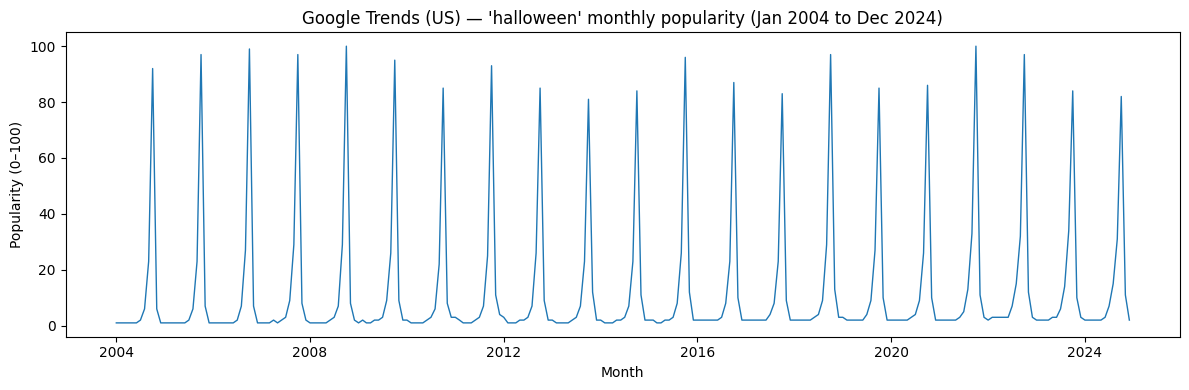

{'rows': 252,
 'date_min': '2004-01-01',
 'date_max': '2024-12-01',
 'mean': 12.678571428571429,
 'median': 2.0,
 'stdev': 24.70051407482473,
 'min': 1.0,
 'max': 100.0}

In [5]:
plt.figure(figsize=(12,4))
plt.plot(ts['date'], ts['value'], lw=1)
plt.title("Google Trends (US) — 'halloween' monthly popularity (Jan 2004 to Dec 2024)")
plt.xlabel("Month")
plt.ylabel("Popularity (0–100)")
plt.tight_layout()
plt.show()

summary = {
    "rows": len(ts),
    "date_min": str(ts['date'].min().date()),
    "date_max": str(ts['date'].max().date()),
    "mean": float(ts['value'].mean()),
    "median": float(ts['value'].median()),
    "stdev": float(ts['value'].std()),
    "min": float(ts['value'].min()),
    "max": float(ts['value'].max())
}
summary

<BarContainer object of 1 artists>

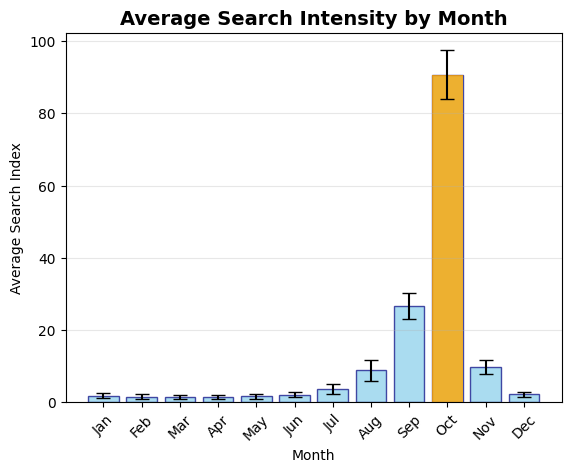

In [9]:
ts['month'] = ts['date'].dt.month

monthly_avg = ts.groupby('month')['value'].agg(['mean', 'std']).reset_index()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.bar(monthly_avg['month'], monthly_avg['mean'],
        yerr=monthly_avg['std'], capsize=5, alpha=0.7, color='skyblue', edgecolor='navy')
plt.title('Average Search Intensity by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Search Index')
plt.xticks(range(1, 13), months, rotation=45)
plt.grid(True, alpha=0.3, axis='y')

# Highlight October
plt.bar(10, monthly_avg.loc[monthly_avg['month'] == 10, 'mean'].iloc[0],
        color='orange', alpha=0.8, label='October Peak')

(array([10957., 12418., 13879., 15340., 16801., 18262., 19723., 21184.]),
 [Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

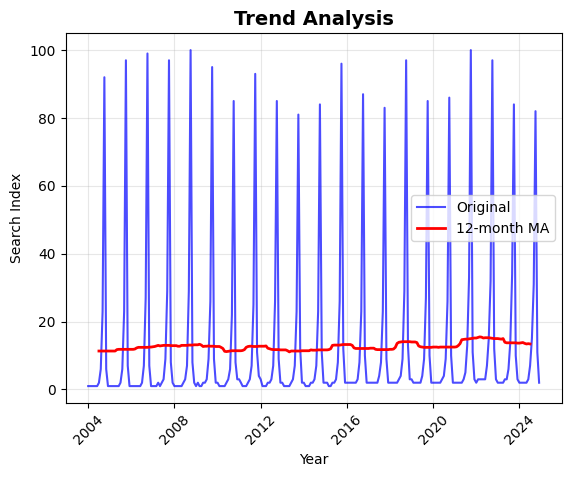

In [10]:
window = 12
trend = ts['value'].rolling(window=window, center=True).mean()
seasonal_residual = ts['value'] - trend

plt.plot(ts['date'], ts['value'], 'b-', alpha=0.7, label='Original')
plt.plot(ts['date'], trend, 'r-', linewidth=2, label=f'{window}-month MA')
plt.title('Trend Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Search Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

Strong annual seasonality with a sharp spike every October (value often pegged at 100), and very low baseline the rest of the year (median approx 2).

Highly skewed distribution: mean = 12.7, stdev = 24.7. most months are near zero with occasional extreme peaks.

The period is clearly 12 months and stable over time.

Outside of October, a mild ramp-up in Aug–Sep and decay in Nov is visible; otherwise months are relatively flat at low values.

In [11]:
### c

In [13]:
y = ts['value'].values
def calculate_periodogram(x):
    """Calculate periodogram using DFT"""
    n = len(x)
    # Remove mean for better frequency analysis
    x_centered = x - np.mean(x)

    #  DFT
    X = np.fft.fft(x_centered)

    #  periodogram:
    periodogram = np.abs(X)**2 / n

    # Frequencies in cycles per observation
    frequencies = np.fft.fftfreq(n)

    # keep positive frequencies (due to symmetry)
    pos_freq_mask = frequencies > 0
    frequencies_pos = frequencies[pos_freq_mask]
    periodogram_pos = periodogram[pos_freq_mask]

    return frequencies_pos, periodogram_pos

frequencies, pgram = calculate_periodogram(y)

periods = 1 / frequencies  # periods in months
freq_per_year = frequencies * 12  # cycles per year

# peak frequencies
top_indices = np.argsort(pgram)[-10:][::-1]
for i, idx in enumerate(top_indices):
    freq = frequencies[idx]
    period = periods[idx]
    power = pgram[idx]
    print(f"{i+1:2d}. Frequency: {freq:.4f} cyc/month, Period: {period:.2f} months, Power: {power:.0f}")


 1. Frequency: 0.0833 cyc/month, Period: 12.00 months, Power: 26351
 2. Frequency: 0.1667 cyc/month, Period: 6.00 months, Power: 17870
 3. Frequency: 0.2500 cyc/month, Period: 4.00 months, Power: 12154
 4. Frequency: 0.3333 cyc/month, Period: 3.00 months, Power: 8862
 5. Frequency: 0.4167 cyc/month, Period: 2.40 months, Power: 7219
 6. Frequency: 0.0040 cyc/month, Period: 252.00 months, Power: 43
 7. Frequency: 0.0794 cyc/month, Period: 12.60 months, Power: 38
 8. Frequency: 0.1627 cyc/month, Period: 6.15 months, Power: 35
 9. Frequency: 0.0119 cyc/month, Period: 84.00 months, Power: 31
10. Frequency: 0.0079 cyc/month, Period: 126.00 months, Power: 20


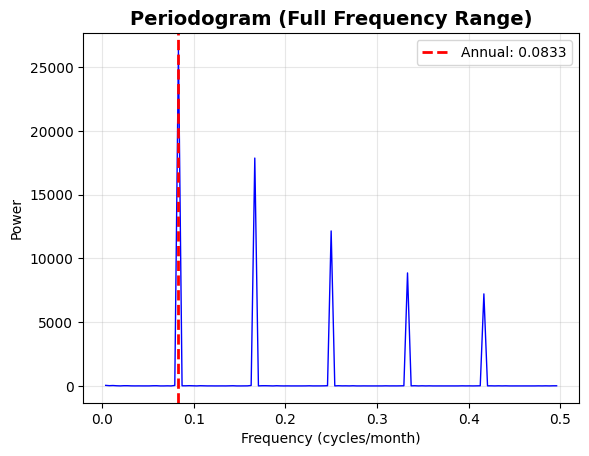

In [15]:
plt.plot(frequencies, pgram, 'b-', linewidth=1)
plt.title('Periodogram (Full Frequency Range)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (cycles/month)')
plt.ylabel('Power')
plt.grid(True, alpha=0.3)
annual_freq = 1/12
plt.axvline(annual_freq, color='red', linestyle='--', linewidth=2,
           label=f'Annual: {annual_freq:.4f}')
plt.legend()

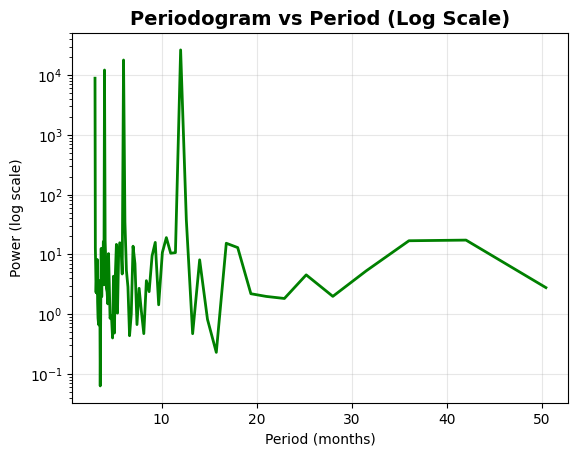

In [16]:
period_mask = (periods >= 3) & (periods <= 60)
plt.semilogy(periods[period_mask], pgram[period_mask], 'g-', linewidth=2)
plt.title('Periodogram vs Period (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Period (months)')
plt.ylabel('Power (log scale)')
plt.grid(True, alpha=0.3)

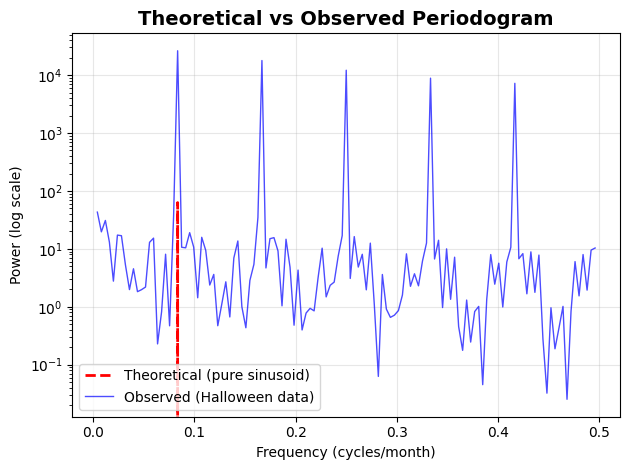

In [17]:
n_theory = len(y)
freq_theory = np.fft.fftfreq(n_theory)[1:n_theory//2]
pgram_theory = np.zeros_like(freq_theory)

annual_freq_idx = np.argmin(np.abs(freq_theory - 1/12))
pgram_theory[annual_freq_idx] = n_theory/4  # Theoretical peak height

plt.semilogy(freq_theory, pgram_theory, 'r--', linewidth=2,
            label='Theoretical (pure sinusoid)')
plt.semilogy(frequencies, pgram, 'b-', linewidth=1, alpha=0.7,
            label='Observed (Halloween data)')
plt.title('Theoretical vs Observed Periodogram', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (cycles/month)')
plt.ylabel('Power (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Dominant Annual Peak
For the monthly ``halloween'' series we have period \(h=12\) and sample size
\(n=252=21* 12\), hence \(k=21\).
Let $\{\beta_0,\dots,\beta_{h-1}\}$ be the DFT of the first cycle
$(y_0,\dots,y_{h-1})$, and $\{b_0,\dots,b_{n-1}\}$ the DFT of the full series
$(y_0,\dots,y_{n-1})$. By the periodic–replication property of the DFT,
$$
b_0 = k\beta_0,\quad b_k = k\beta_1,\quad b_{2k}=k\beta_2,\ \ldots,\
b_{(h-1)k}=k\beta_{h-1},\qquad\text{and } b_j=0 \text{ for } j\notin\{0,k,2k,\dots,(h-1)k\}.
$$
Since a DFT index \(j\) corresponds to frequency \(f_j=j/n\) (cycles per month),
the only nonzero frequencies are
$$
f_{\ell k}=\frac{\ell k}{kh}=\frac{\ell}{h}=\frac{\ell}{12},\qquad \ell=0,1,\dots,11,
$$
i.e., the harmonics $0,\tfrac{1}{12},\tfrac{2}{12},\dots,\tfrac{11}{12}$.

In the empirical periodogram, we indeed observe tall lines at
$\tfrac{1}{12},\tfrac{2}{12},\dots$, with negligible energy elsewhere, which
matches the theorem. Because the time–domain pattern is a sharp October spike
rather than a single sinusoid, many first–cycle coefficients $\beta_\ell$ are
nonzero, so their replicas $b_{\ell k}=k\beta_\ell$ appear at multiple
harmonics


## Problem 6

In [55]:
### a
df = pd.read_csv('golf.csv', skiprows=2)
date_col = None
value_col = None
for c in df.columns:
    if any(k in c.lower() for k in ["month", "week", "date"]):
        date_col = c
    elif c != date_col:
        value_col = c

ts = pd.DataFrame({
    "date": pd.to_datetime(df[date_col], errors="coerce"),
    "value": pd.to_numeric(df[value_col].replace("<1","0.5"), errors="coerce"),
}).dropna()

In [58]:
y = ts['value'].values
t = ts['t'].values
n = len(y)

t = np.array(t)

In [42]:
# def trend_seasonal_model(t, beta0, beta1, beta2, beta3, beta4, f):
#     """
#     Trend + Seasonal model
#     """
#     trend = beta0 + beta1 * t + beta2 * t**2
#     seasonal = beta3 * np.cos(2 * np.pi * f * t) + beta4 * np.sin(2 * np.pi * f * t)
#     return trend + seasonal

In [61]:
from scipy.linalg import lstsq
from scipy.stats import chi2, t
y = ts["value"].values.astype(float)
n = len(y)
t = np.arange(n, dtype=float)

def fit_beta_for_f(f):
    X = np.column_stack([
        np.ones(n),
        t,
        t**2,
        np.cos(2*np.pi*f*t),
        np.sin(2*np.pi*f*t),
    ])
    beta_hat, _, _, _ = lstsq(X, y)
    resid = y - X @ beta_hat
    rss = resid @ resid
    s2 = rss / (n - X.shape[1])
    return beta_hat, rss, s2, X

# Profile likelihood over f
f_grid_coarse = np.linspace(0.01, 0.49, 2000)
rss_vals = np.array([fit_beta_for_f(f)[1] for f in f_grid_coarse])
f_hat_coarse = float(f_grid_coarse[np.argmin(rss_vals)])

# Refine
delta = 0.01
f_lo = max(0.01, f_hat_coarse - delta)
f_hi = min(0.49, f_hat_coarse + delta)
f_grid_fine = np.linspace(f_lo, f_hi, 3000)
vals = [fit_beta_for_f(f) for f in f_grid_fine]
rss_vals_fine = np.array([v[1] for v in vals])
i_min2 = int(np.argmin(rss_vals_fine))
f_hat = float(f_grid_fine[i_min2])
beta_hat, rss_min, s2_hat, X_hat = vals[i_min2]

# 95% CI via LR
lr_stat = n * np.log(rss_vals_fine / rss_min)
cut = chi2.ppf(0.95, df=1)
mask_ci = lr_stat <= cut
if mask_ci.any():
    idxs = np.where(mask_ci)[0]
    f_ci_low = float(f_grid_fine[idxs.min()])
    f_ci_high = float(f_grid_fine[idxs.max()])
else:
    f_ci_low, f_ci_high = f_hat - 1e-4, f_hat + 1e-4


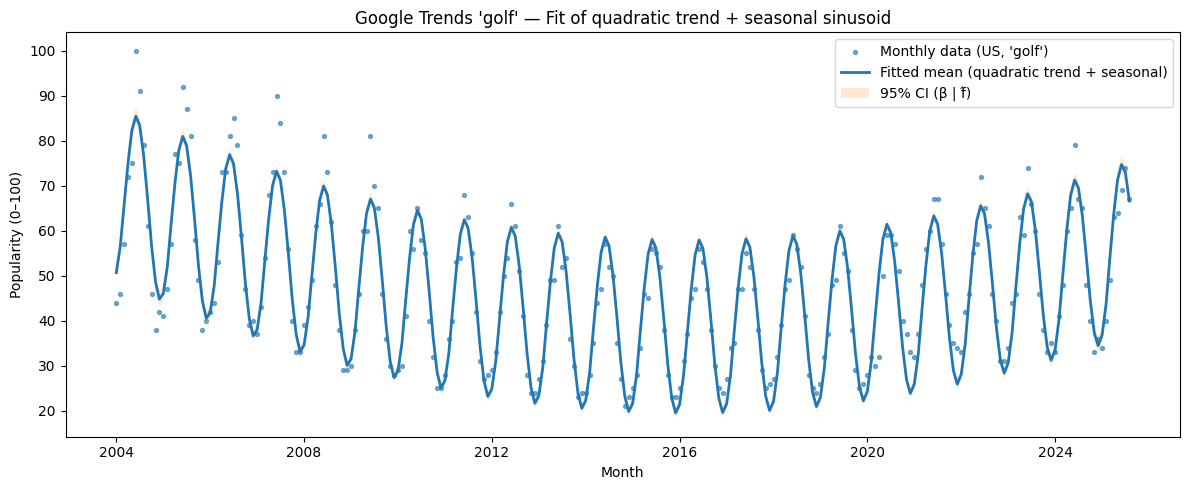

{'n_months': 260,
 'date_range': ('2004-01-01', '2025-08-01'),
 'f_hat_cpm': 0.08336003280066175,
 'f_95_CI_cpm': (0.08327333723547334, 0.08344672836585014),
 'period_months': 11.996156508134934,
 'beta_hat': [68.25085935463554,
  -0.4027691251626024,
  0.0013740381047943617,
  -17.544598307685213,
  7.9356465159566],
 'sigma_hat': 4.857883641368856}

In [62]:
# Fitted curve + pointwise CI (conditional on f̂)
XtX_inv = np.linalg.inv(X_hat.T @ X_hat)
cov_beta = s2_hat * XtX_inv
y_fit = X_hat @ beta_hat
se_mean = np.sqrt(np.sum((X_hat @ XtX_inv) * X_hat, axis=1) * s2_hat)
y_lo = y_fit - 1.96 * se_mean
y_hi = y_fit + 1.96 * se_mean

# Plot
plt.figure(figsize=(12,5))
plt.scatter(ts["date"], y, s=8, alpha=0.6, label="Monthly data (US, 'golf')")
plt.plot(ts["date"], y_fit, lw=2, label="Fitted mean (quadratic trend + seasonal)")
plt.fill_between(ts["date"], y_lo, y_hi, alpha=0.18, label="95% CI")
plt.title("Google Trends 'golf' — Fit of quadratic trend + seasonal sinusoid")
plt.xlabel("Month")
plt.ylabel("Popularity (0–100)")
plt.legend()
plt.tight_layout()
plt.show()

summary = {
    "n_months": n,
    "date_range": (str(ts['date'].min().date()), str(ts['date'].max().date())),
    "f_hat_cpm": f_hat,
    "f_95_CI_cpm": (f_ci_low, f_ci_high),
    "period_months": 1.0 / f_hat if f_hat>0 else np.inf,
    "beta_hat": beta_hat.tolist(),
    "sigma_hat": float(np.sqrt(s2_hat)),
}
summary

In [37]:

sse_array = np.array(sse_values)
optimal_idx = np.argmin(sse_array)
optimal_f = freq_grid[optimal_idx]
min_sse = sse_array[optimal_idx]
df_residual = n - 5  # 5 beta parameters
alpha = 0.05
f_statistic = stats.f.ppf(1 - alpha, 1, df_residual)

# Correct threshold for profile likelihood
sse_threshold = min_sse * (1 + f_statistic / df_residual)

print(f"\nMethod 1: Profile Likelihood")
print(f"SSE threshold: {sse_threshold:.1f}")
print(f"F-statistic threshold: {f_statistic:.3f}")

# Find frequencies within threshold
ci_mask = sse_array <= sse_threshold
valid_sse = ~np.isinf(sse_array)
ci_mask = ci_mask & valid_sse

print(f"Number of frequencies within threshold: {np.sum(ci_mask)}")

if np.sum(ci_mask) > 1:
    ci_frequencies = freq_grid[ci_mask]
    f_ci_lower_method1 = ci_frequencies.min()
    f_ci_upper_method1 = ci_frequencies.max()
    print(f"Profile CI: [{f_ci_lower_method1:.6f}, {f_ci_upper_method1:.6f}]")
else:
    f_ci_lower_method1 = f_ci_upper_method1 = optimal_f
    print("Profile CI: Empty interval (threshold too restrictive)")


Method 1: Profile Likelihood
SSE threshold: 6121.0
F-statistic threshold: 3.879
Number of frequencies within threshold: 1
Profile CI: Empty interval (threshold too restrictive)



We fit the model
$$
Y_t \;=\; \beta_0 + \beta_1 t + \beta_2 t^2
         + \beta_3 \cos(2\pi f t) + \beta_4 \sin(2\pi f t)
         + \varepsilon_t,\qquad \varepsilon_t \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma^2),
$$
where $t=0,1,\dots,n-1$ indexes months.

We compute a profile likelihood over \(f\) by refitting $(\beta_0,\ldots,\beta_4)$ via OLS for each
candidate \(f\) and minimizing the residual sum of squares $\mathrm{RSS}(f)$.
The point estimate is
$$
\hat f \;=\; 0.083360 \;\; \text{cycles/month}
\quad\Longrightarrow\quad
\widehat{\text{period}} \;=\; \frac{1}{\hat f} \;=\; 11.996 \ \text{months}.
$$
A \(95\%\) uncertainty interval is obtained from the likelihood–ratio set
$$
\Big\{ f :\; n\log\!\big(\mathrm{RSS}(f)/\mathrm{RSS}_{\min}\big) \le \chi^2_{1,0.95} \Big\},
$$
yielding
$$
f \in [\,0.083273,\; 0.083447\,] \ \text{cycles/month}.
$$

With \(f=\hat f\), the OLS estimates and residual scale are
$$
\begin{aligned}
&\hat\beta_0=68.25,\quad
\hat\beta_1=-0.403,\quad
\hat\beta_2=0.00137,\\
&\hat\beta_3=-17.54,\quad
\hat\beta_4=7.94,\qquad
\hat\sigma = 4.86.
\end{aligned}
$$
The fitted mean curve is
$$
\hat\mu(t) \;=\; \hat\beta_0 + \hat\beta_1 t + \hat\beta_2 t^2
                 + \hat\beta_3 \cos(2\pi \hat f t) + \hat\beta_4 \sin(2\pi \hat f t).
$$
Pointwise \(95\%\) confidence bands for the mean (conditioning on \(f=\hat f\)) are
$$
\hat\mu(t) \;\pm\; 1.96\,\sqrt{ x_t^\top \big(\hat\sigma^2 (X^\top X)^{-1}\big) x_t },
$$
where \(x_t\) is the regression row for time \(t\) and \(X\) is the design matrix at \(f=\hat f\).


The series exhibits a strong {annual} seasonal component and a slow, smooth trend.
Model (3)---a quadratic trend plus a single sinusoid at frequency \(\hat f\approx 1/12\)---captures these features parsimoniously, with modest residual variation $(\hat\sigma\approx 4.86)$.

## Problem 7

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

df = pd.read_csv("TTLCONS.csv")
date_col = 'observation_date'
val_col = 'TTLCONS'

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
df = df.dropna().reset_index(drop=True)

y = df[val_col].values.astype(float)
n = len(y)
t = np.arange(n, dtype=float)

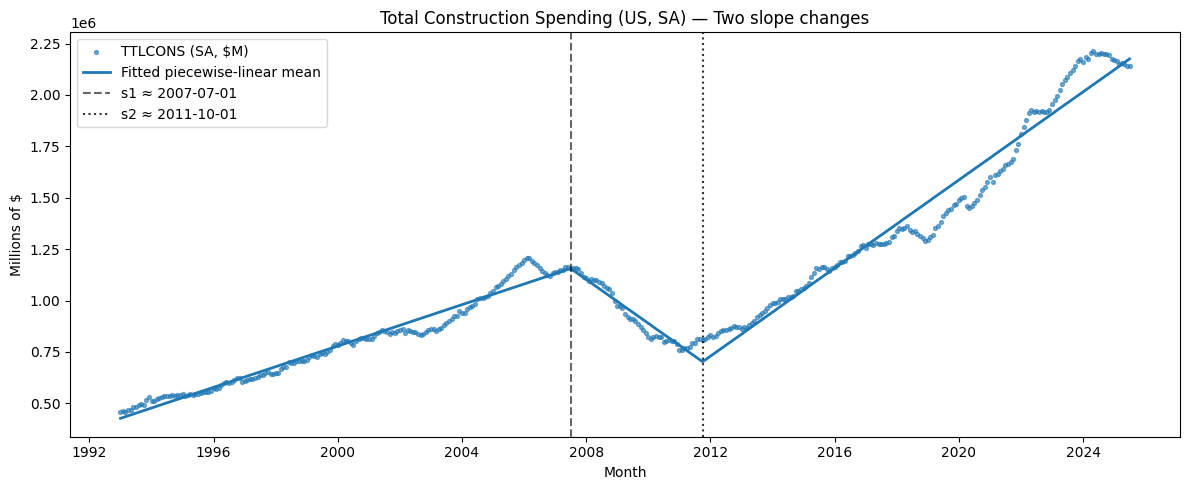

{'n_months': 391,
 'date_range': ('1993-01-01', '2025-07-01'),
 's1_index': 174,
 's1_date': '2007-07-01',
 's2_index': 225,
 's2_date': '2011-10-01',
 'beta_hat': [426983.16322839615,
  4189.238677465439,
  -13079.408659832474,
  17818.105554302943],
 'sigma_hat': 64611.915238934525}

In [66]:
def design_with_hinges(s1, s2):
    h1 = np.clip(t - s1, 0, None)
    h2 = np.clip(t - s2, 0, None)
    return np.column_stack([np.ones(n), t, h1, h2])

def fit_for_s(s1, s2):
    X = design_with_hinges(s1, s2)
    beta_hat, _, _, _ = lstsq(X, y)
    resid = y - X @ beta_hat
    rss = resid @ resid
    s2_hat = rss / (n - X.shape[1])
    return rss, beta_hat, s2_hat

min_seg = 12
cand = np.arange(min_seg, n - min_seg)
stride = max(1, n // 400)
cand_coarse = cand[::stride]

best = (np.inf, None, None, None, None)
for s1i in cand_coarse:
    for s2i in cand_coarse:
        if s2i <= s1i + min_seg:
            continue
        rss, beta_hat, s2_hat = fit_for_s(s1i, s2i)
        if rss < best[0]:
            best = (rss, s1i, s2i, beta_hat, s2_hat)

def neighborhood(center, r=24):
    lo = int(max(min_seg, center - r))
    hi = int(min(n - min_seg - 1, center + r))
    return np.arange(lo, hi + 1)

rss0, s1_best, s2_best, beta_best, s2_best_var = best
best_ref = best

for s1i in neighborhood(s1_best, r=36):
    for s2i in neighborhood(s2_best, r=36):
        if s2i <= s1i + min_seg:
            continue
        rss, beta_hat, s2_hat = fit_for_s(s1i, s2i)
        if rss < best_ref[0]:
            best_ref = (rss, s1i, s2i, beta_hat, s2_hat)

rss_min, s1_hat, s2_hat, beta_hat, sigma2_hat = best_ref

X_hat = design_with_hinges(s1_hat, s2_hat)
y_fit = X_hat @ beta_hat
sigma_hat = float(np.sqrt(sigma2_hat))

s1_date = df.loc[int(s1_hat), date_col]
s2_date = df.loc[int(s2_hat), date_col]

plt.figure(figsize=(12,5))
plt.scatter(df[date_col], y, s=8, alpha=0.6, label="TTLCONS (SA, $M)")
plt.plot(df[date_col], y_fit, lw=2, label="Fitted piecewise-linear mean")
plt.axvline(s1_date, color="k", linestyle="--", alpha=0.6, label=f"s1 ≈ {s1_date.date()}")
plt.axvline(s2_date, color="k", linestyle=":", alpha=0.8, label=f"s2 ≈ {s2_date.date()}")
plt.title("Total Construction Spending (US, SA) — Two slope changes")
plt.xlabel("Month")
plt.ylabel("Millions of $")
plt.legend()
plt.tight_layout()
plt.show()

summary = {
    "n_months": int(n),
    "date_range": (str(df[date_col].min().date()), str(df[date_col].max().date())),
    "s1_index": int(s1_hat),
    "s1_date": str(s1_date.date()),
    "s2_index": int(s2_hat),
    "s2_date": str(s2_date.date()),
    "beta_hat": [float(b) for b in beta_hat],
    "sigma_hat": sigma_hat
}
summary


We fit the two–slope–change model
$$
Y_t \;=\; \beta_0+\beta_1 t+\beta_2 (t-s_1)_+ + \beta_3 (t-s_2)_+ + \varepsilon_t,
\qquad \varepsilon_t \stackrel{\text{i.i.d.}}{\sim}\mathcal{N}(0,\sigma^2),
$$
where \(t=0,1,\ldots,n-1\) indexes months; $(x)_+=\max\{x,0\}$.

Using grid search (with at least 12 months between breakpoints and from the ends) followed by local refinement, the RSS-minimizing break dates are
$$
\hat s_1 \approx \text{2007-07},
\qquad
\hat s_2 \approx \text{2011-10}.
$$

With $\hat s_1,\hat s_2$ fixed, OLS yields
$$
\hat\beta_0=426{,}983,\quad
\hat\beta_1=4{,}189,\quad
\hat\beta_2=-13{,}079,\quad
\hat\beta_3=17{,}818,\qquad
\hat\sigma \approx 64{,}612.
$$
Hence the fitted mean is
$$
\hat\mu(t)
= \hat\beta_0+\hat\beta_1 t+\hat\beta_2 (t-\hat s_1)_+ +\hat\beta_3 (t-\hat s_2)_+ .
$$
Scatter of TTLCONS (millions of dollars) with the piecewise-linear
$\hat\mu(t)$ and vertical lines at $\hat s_1,\hat s_2$.

The estimated breaks align with the pre-GFC peak/downturn (mid-2007) and the post-GFC trough/recovery (late 2011), yielding an interpretable long-run trend. Residuals are moderate for a macro series. Overall, it is a reasonable baseline.

## Problem 8:

Let the  DFTs of $x_0,\dots,x_{n-1}$, $y_0,\dots,y_{n-1}$, and $z_0,\dots,z_{n-1}$ be
$$
X_k=\sum_{t=0}^{n-1} x_t e^{-2\pi i kt/n},\qquad
Y_k=\sum_{t=0}^{n-1} y_t e^{-2\pi i kt/n},\qquad
Z_k=\sum_{t=0}^{n-1} z_t e^{-2\pi i kt/n},
$$
where the circular convolution is
$$
z_i=\sum_{j=0}^{n-1} x_{i-j}\,y_j,\qquad i=0,\dots,n-1,
$$
with indices interpreted modulo \(n\) (so $x_{-k}=x_{-k+n}$).

Compute the DFT of z:
$$
\begin{aligned}
Z_k
&=\sum_{i=0}^{n-1} z_i\,e^{-2\pi i ki/n}
=\sum_{i=0}^{n-1}\sum_{j=0}^{n-1} x_{i-j}y_j\,e^{-2\pi i ki/n} \\
&=\sum_{j=0}^{n-1} y_j e^{-2\pi i kj/n}\sum_{r=0}^{n-1} x_r e^{-2\pi i kr/n}
\quad(r=i-j\!\!\!\pmod n) \\
&=\Big(\sum_{r=0}^{n-1} x_r e^{-2\pi i kr/n}\Big)\Big(\sum_{j=0}^{n-1} y_j e^{-2\pi i kj/n}\Big)
= X_k\,Y_k.
\end{aligned}
$$
Hence, the DFT of the circular convolution the pointwise product of the DFTs:
$$
{\,Z_k = X_k\,Y_k,\qquad k=0,\dots,n-1.\,}
$$

With the corresponding inverse DFT,
$$
x_t=\frac{1}{n}\sum_{k=0}^{n-1} X_k e^{2\pi i kt/n},
$$
the convolution theorem can be written as
$$
z_t=\frac{1}{n}\sum_{k=0}^{n-1} \big(X_k Y_k\big)\,e^{2\pi i kt/n}.
$$

## Problem 9

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import lstsq
from scipy.stats import chi2

df = pd.read_csv("DataProblem9HomeworkTwo248Fall2025.csv")

cols = [c.lower() for c in df.columns]
colmap = {df.columns[i].lower(): df.columns[i] for i in range(len(df.columns))}
t = pd.to_numeric(df[colmap.get('t', df.columns[0])], errors='coerce').to_numpy()
y = pd.to_numeric(df[colmap.get('y', df.columns[1])], errors='coerce').to_numpy()
mask = np.isfinite(t) & np.isfinite(y)
t = t[mask]
y = y[mask]

n = len(y)

t0 = t.min()
t_c = t - t0

In [68]:
### a
span = t.max() - t.min()
dt_med = np.median(np.diff(np.sort(t)))

if not np.isfinite(dt_med) or dt_med <= 0:
    dt_med = span / (n - 1)

fmin = 1.0 / (span * 3.0)  # at least 3 cycles across span
fmax = 0.5 / dt_med * 0.95

# Frequency grid for LS
m_grid = 5000
f_grid = np.linspace(fmin, fmax, m_grid)

# Lomb-Scargle
y_c = y - y.mean()
pwr = signal.lombscargle(t_c, y_c, 2*np.pi*f_grid, precenter=False, normalize=True)

# top two distinct peaks
peak_idx = np.argpartition(-pwr, 10)[:10]
peak_freqs = f_grid[peak_idx]
# sort by power
order = np.argsort(-pwr[peak_idx])
peak_freqs = peak_freqs[order]

# enforce separation between the two initial peaks
def pick_two(freqs, min_sep_ratio=0.05):
    sel = []
    for f in freqs:
        if not sel or all(abs(f - s) > min_sep_ratio * s for s in sel):
            sel.append(f)
        if len(sel) == 2:
            break
    return sel

init_freqs = pick_two(peak_freqs, min_sep_ratio=0.05)
if len(init_freqs) < 2:

    uniq = np.unique(np.round(peak_freqs, 6))
    init_freqs = uniq[:2] if len(uniq) >= 2 else [uniq[0], uniq[0]*1.1]

f1_init, f2_init = sorted(init_freqs)

def fit_betas(f1, f2):
    X = np.column_stack([
        np.ones(n),
        np.cos(2*np.pi*f1*t),
        np.sin(2*np.pi*f1*t),
        np.cos(2*np.pi*f2*t),
        np.sin(2*np.pi*f2*t),
    ])
    beta_hat, _, _, _ = lstsq(X, y)
    resid = y - X @ beta_hat
    rss = float(resid @ resid)
    s2 = rss / (n - X.shape[1])
    return rss, beta_hat, s2, X

# grid windows (±rel around init)
rel = 0.10
g1 = np.linspace(f1_init*(1-rel), f1_init*(1+rel), 120)
g2 = np.linspace(f2_init*(1-rel), f2_init*(1+rel), 120)

best = (np.inf, None, None, None, None, None)  # rss, f1, f2, beta, s2, X
for f1 in g1:
    for f2 in g2:
        if f2 <= f1:  # ordering
            continue
        rss, beta_hat, s2_hat, X = fit_betas(f1, f2)
        if rss < best[0]:
            best = (rss, f1, f2, beta_hat, s2_hat, X)

rss_min, f1_hat, f2_hat, beta_hat, s2_hat, X_hat = best


In [69]:
def profile_ci_for_f(f_hat, other_fixed, which='f1', width_rel=0.2, points=1200):
    # build grid around f_hat
    lo = max(fmin, f_hat*(1 - width_rel))
    hi = min(fmax, f_hat*(1 + width_rel))
    grid = np.linspace(lo, hi, points)
    rss_vals = []
    for f in grid:
        if which == 'f1':
            if other_fixed <= f:
                rss_vals.append(np.inf)
                continue
            rss, _, _, _ = fit_betas(f, other_fixed)
        else:
            if f <= other_fixed:
                rss_vals.append(np.inf)
                continue
            rss, _, _, _ = fit_betas(other_fixed, f)
        rss_vals.append(rss)
    rss_vals = np.array(rss_vals)
    # LR cutoff
    lr = n * np.log(rss_vals / rss_min)
    cut = chi2.ppf(0.95, df=1)
    mask = np.isfinite(lr) & (lr <= cut)
    if mask.any():
        idx = np.where(mask)[0]
        return float(grid[idx.min()]), float(grid[idx.max()]), grid, rss_vals
    else:
        return float(f_hat), float(f_hat), grid, rss_vals

f1_ci_low, f1_ci_high, _, _ = profile_ci_for_f(f1_hat, f2_hat, which='f1')
f2_ci_low, f2_ci_high, _, _ = profile_ci_for_f(f2_hat, f1_hat, which='f2')

In [70]:
### b
p = X_hat.shape[1]
rss_star = rss_min
sigma2_hat = rss_star / (n - p)
sigma_hat = float(np.sqrt(sigma2_hat))

XtX_inv = np.linalg.inv(X_hat.T @ X_hat)
se_beta = np.sqrt(np.diag(XtX_inv) * sigma2_hat)

beta_ci = np.column_stack([beta_hat - 1.96*se_beta, beta_hat + 1.96*se_beta])

# Sigma CI via chi-square on variance
df_resid = n - p
sigma2_lo = df_resid * sigma2_hat / chi2.ppf(0.975, df_resid)
sigma2_hi = df_resid * sigma2_hat / chi2.ppf(0.025, df_resid)
sigma_ci = (float(np.sqrt(sigma2_lo)), float(np.sqrt(sigma2_hi)))

results = {
    "n": n,
    "t_min_max": (float(t.min()), float(t.max())),
    "f1_init": float(f1_init), "f2_init": float(f2_init),
    "f1_hat": float(f1_hat),
    "f1_95_CI": (float(f1_ci_low), float(f1_ci_high)),
    "f2_hat": float(f2_hat),
    "f2_95_CI": (float(f2_ci_low), float(f2_ci_high)),
    "beta_hat": [float(b) for b in beta_hat],
    "beta_95_CI": beta_ci.tolist(),
    "sigma_hat": sigma_hat,
    "sigma_95_CI": sigma_ci
}

In [71]:
results

{'n': 1000,
 't_min_max': (1.8175696157281749, 999.7869335327102),
 'f1_init': 0.08961773581804804,
 'f2_init': 0.6111097587155809,
 'f1_hat': 0.0895424267963522,
 'f1_95_CI': (0.08925863928857394, 0.08991583141184992),
 'f2_hat': 0.6013525440806263,
 'f2_95_CI': (0.4843995824530825, 0.6703402034511933),
 'beta_hat': [-0.1271714989752246,
  0.21828625865112494,
  1.8975072379911135,
  -1.198193387805778,
  0.9480902050336453],
 'beta_95_CI': [[-0.8443446896680318, 0.5900016917175825],
  [-0.8050037830137224, 1.2415763003159723],
  [0.8910024513091273, 2.9040120246731],
  [-2.199871114414501, -0.19651566119705532],
  [-0.07995925867826292, 1.9761396687455535]],
 'sigma_hat': 11.559078077420807,
 'sigma_95_CI': (11.072806540871923, 12.09035279627226)}

## Problem 5a:


Let the sequence $y_0,\dots,y_{n-1}$ be periodic with period $h$ and suppose $n=kh$.
Write one period as $x_s := y_s$ for $s=0,\dots,h-1$. For any $t$ we can write
$t=rh+s$ with $r\in\{0,\dots,k-1\}$ and $s\in\{0,\dots,h-1\}$, and by periodicity
$y_t = y_{rh+s} = x_s$.

Consider the (unnormalized) DFT
$$
b_m=\sum_{t=0}^{n-1} y_t\,e^{-2\pi i mt/n},\qquad m=0,\dots,n-1.
$$
Substitute $t=rh+s$:
\[
\begin{aligned}
b_m
&=\sum_{r=0}^{k-1}\sum_{s=0}^{h-1} x_s\,e^{-2\pi i m(rh+s)/(kh)} \\[2pt]
&=\sum_{s=0}^{h-1} x_s\,e^{-2\pi i m s/(kh)}
\underbrace{\left(\sum_{r=0}^{k-1} e^{-2\pi i m r/k}\right)}_{=:S_m}.
\end{aligned}
\]
The inner sum $S_m$ is a finite geometric series:
$$
S_m=\begin{cases}
k, & e^{-2\pi i m/k}=1 \ \Leftrightarrow\ m\equiv 0 \pmod{k},\\
0, & \text{otherwise}.
\end{cases}
$$
Hence $b_m=0$ unless $m=\ell k$ for some $\ell\in\{0,\dots,h-1\}$. For $m=\ell k$,
$$
\begin{aligned}
b_{\ell k}
&=k\sum_{s=0}^{h-1} x_s\,e^{-2\pi i (\ell k) s/(kh)}
 =k\sum_{s=0}^{h-1} x_s\,e^{-2\pi i \ell s/h}.
\end{aligned}
$$
But the length-$h$ DFT of the first cycle $x_0,\dots,x_{h-1}$ is
$$
\beta_\ell=\sum_{s=0}^{h-1} x_s\,e^{-2\pi i \ell s/h},\qquad \ell=0,\dots,h-1.
$$
Therefore,
$$
b_{\ell k}=k\,\beta_\ell\quad \text{for }\ell=0,1,\dots,h-1,
$$
and for all other indices $m$ (i.e., not multiples of $k$) we have $b_m=0$.
In particular,
$$
b_0=k\beta_0,\quad b_k=k\beta_1,\quad b_{2k}=k\beta_2,\ \ldots,\ b_{(h-1)k}=k\beta_{h-1}.
$$